# Desarrollo de Tema

# Red Neuronal en Grafos (GNN)

En este ejemplo introductorio sobre la construcción de una GNN, se considera un pequeño conjunto de datos asociado a una **plataforma de redes sociales**, donde:
- cada nodo representa una persona y
- cada arista entre dos nodos representa una relación de amistad.

Además, cada nodo (persona) cuenta con características asociadas, como la edad, intereses, entre otros atributos.

La tarea objetivo de la GNN consiste en **clasificar a las personas como populares o no populares** dentro de la red social (clasificación binaria). Esta clasificación se basa en si una persona tiene más de dos amigos o menos de dos, teniendo en cuenta:

- Las características propias de la persona, como sus intereses  
- Las conexiones de la persona con otros individuos en la red  

De este modo, las GNN introducen un nivel adicional de sofisticación en las tareas predictivas, ya que no solo consideran las características de la instancia objetivo para realizar una predicción, sino también sus relaciones con otras instancias de datos. 

Esto contrasta con los modelos clásicos de clasificación y regresión, que generalmente no incorporan explícitamente la estructura relacional del conjunto de datos.

In [1]:
import os
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torchinfo import summary

## Conjunto de Datos: Mini Red Social

Se define un pequeño conjunto de datos en forma de grafo que representa una red social simplificada, donde los nodos corresponden a personas y las aristas representan relaciones de amistad entre ellas.

### Representación de Conexiones: `edge_index`
- La matriz `edge_index` representa las conexiones o aristas entre los usuarios del grafo
- En este caso, existen 5 usuarios, identificados con índices de 0 a 4.

Cada columna de la matriz indica una conexión dirigida entre dos nodos. 
- Por ejemplo, la primera conexión va del usuario 0 al usuario 1, lo cual se identifica tomando el primer elemento de cada fila. 
- La segunda conexión corresponde a la relación inversa, es decir, del usuario 1 al usuario 0.
- Posteriormente, se observan conexiones como la del usuario 0 al usuario 2, y así sucesivamente.

Se destaca que el usuario 3 no presenta conexiones en esta representación, por lo que se encuentra aislado dentro del grafo.

In [2]:
# Define graph dataset
edge_index = torch.tensor([
    [0, 1, 0, 2, 0, 4, 2, 4],
    [1, 0, 2, 0, 4, 0, 4, 2],
], dtype=torch.long)

print("edge_index: ",edge_index)
print(edge_index.shape)


edge_index:  tensor([[0, 1, 0, 2, 0, 4, 2, 4],
        [1, 0, 2, 0, 4, 0, 4, 2]])
torch.Size([2, 8])


In [3]:
# MATRIZ DE ADYACENCIA


# Número de nodos (máximo índice + 1)
num_nodes = int(edge_index.max().item()) + 1

# Inicializar matriz de adyacencia
A = torch.zeros((num_nodes, num_nodes))

# Llenar la matriz
for i, j in edge_index.t():
    A[i, j] = 1

# Mostrar matriz en consola
print("Matriz de Adyacencia A:")
print(A)


Matriz de Adyacencia A:
tensor([[0., 1., 1., 0., 1.],
        [1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.],
        [1., 0., 1., 0., 0.]])


### Características de los Nodos: `node_features`

- Se modelan dos características numéricas para cada persona, representadas en un tensor denominado `node_features`.
- Estas características corresponden a la edad de la persona y a su interés en los deportes, donde el valor 1 indica que existe interés y 0 indica que no lo hay.

In [4]:
# Define data features
node_features = torch.tensor([
    [25, 1],  # Person 0 (25 years old, likes sports)
    [30, 0],  # Person 1 (30 years old, does not like sports)
    [22, 1],  # Person 2 (22 years old, likes sports)
    [35, 0],  # Person 3 (35 years old, does not like sports)
    [27, 1],  # Person 4 (27 years old, likes sports)
], dtype=torch.float)

print("Características de los Nodos: \n",node_features)

Características de los Nodos: 
 tensor([[25.,  1.],
        [30.,  0.],
        [22.,  1.],
        [35.,  0.],
        [27.,  1.]])


## Visualización de una Red Neuronal en Grafos en Python

- Una forma de visualizar una red neuronal en grafos en Python consiste en utilizar la biblioteca `NetworkX`, la cual permite construir el grafo a partir de la lista de aristas.
- Posteriormente, se emplea `Matplotlib` para representar gráficamente dicha estructura.

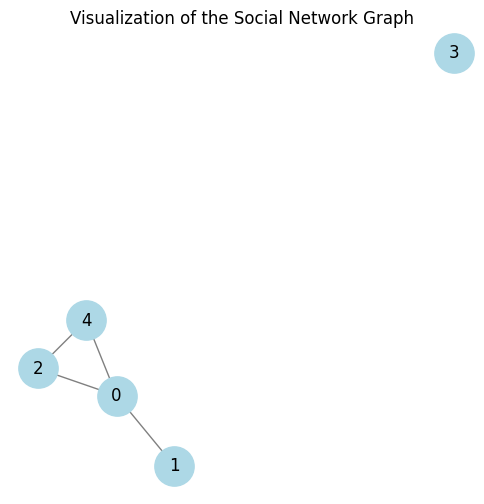

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Convert the edge_index tensor to a list of edge tuples
edge_list = edge_index.t().tolist()

# Create a NetworkX graph from the edge list
G = nx.Graph()
G.add_edges_from(edge_list)

# Optionally, include nodes that might be isolated (e.g., person 3)
G.add_nodes_from(range(node_features.size(0)))

# Generate a layout for the nodes
pos = nx.spring_layout(G, seed=42)  # fixed seed for reproducibility

# Draw the graph with labels
plt.figure(figsize=(6, 6))
nx.draw_networkx(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=800)
plt.title("Visualization of the Social Network Graph")
plt.axis('off')
plt.show()

## Construcción de un Modelo de Red Neuronal en Grafos en Python

- Se definen las etiquetas del conjunto de datos de usuarios, determinando si una persona es popular o no.
- Esta clasificación se basa en si el individuo tiene más de dos amigos dentro de la red.

- El proceso implica calcular el número de conexiones de cada persona (valor real o *ground truth*) a partir de la matriz de adyacencia, lo que permite asignar correctamente la etiqueta correspondiente.

- Se cuenta el número de amigos por persona.

**Regla:**
- ≥ 2 amigos → popular (1)  
- < 2 amigos → no popular (0)

In [6]:
# Define dataset labels
num_friends = torch.tensor([3, 1, 2, 0, 2])
labels = (num_friends >= 2).long()

print("num_friends =",num_friends)
print("labels =",labels)

num_friends = tensor([3, 1, 2, 0, 2])
labels = tensor([1, 0, 1, 0, 1])


### Definición de Máscara y Estructura de Datos

- Se utiliza una máscara para indicar que las tres primeras personas serán empleadas como datos de entrenamiento para construir la GNN, mientras que las dos restantes se reservarán para la fase de inferencia.

- Finalmente, toda la información se organiza y encapsula en un objeto `Data`, el cual estructura el grafo junto con sus características, etiquetas y particiones de entrenamiento.

In [7]:
# Mask for separating training and testing data
train_mask = torch.tensor([1, 1, 1, 0, 0], dtype=torch.bool)
data = Data(x=node_features, edge_index=edge_index, y=labels, train_mask=train_mask)

print("train_mask: ",train_mask)
print("data: ",data)

train_mask:  tensor([ True,  True,  True, False, False])
data:  Data(x=[5, 2], edge_index=[2, 8], y=[5], train_mask=[5])


### Definición de la Arquitectura de la GNN

- El siguiente bloque de código define la arquitectura de la red neuronal en grafos y realiza la instanciación del modelo.

- En PyTorch, los modelos GNN pueden construirse utilizando capas de convolución sobre grafos, como las implementadas por la clase `GCNConv` en `torch_geometric.nn`.
- Estas capas permiten agregar información proveniente de los nodos vecinos, facilitando el aprendizaje de representaciones que no solo capturan las características individuales de cada nodo, sino también las relaciones estructurales presentes en el grafo.


**Arquitectura:**

- GCNConv(2 → 4) → primera capa
- ReLU → activación
- GCNConv(4 → 2) → salida (2 clases)

 **Cada capa:**
- Agrega información de vecinos  
- Aprende representaciones del nodo considerando el grafo

In [8]:
# Define model
class GNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim) 
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)  # Activation function
        x = self.conv2(x, edge_index)
        return x

# Instantiate model
model = GNN(input_dim=2, hidden_dim=4, output_dim=2)

In [9]:
# summary
summary(model)

Layer (type:depth-idx)                   Param #
GNN                                      --
├─GCNConv: 1-1                           4
│    └─SumAggregation: 2-1               --
│    └─Linear: 2-2                       8
├─GCNConv: 1-2                           2
│    └─SumAggregation: 2-3               --
│    └─Linear: 2-4                       8
Total params: 22
Trainable params: 22
Non-trainable params: 0

## Entrenamiento de una Red Neuronal en Grafos en Python

- El proceso de entrenamiento de una red neuronal en grafos es bastante similar al utilizado en otros tipos de modelos de redes neuronales en PyTorch.

In [10]:
# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train model
for epoch in range(400):
    model.train()
    optimizer.zero_grad()
    
    out = model(data)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.8445
Epoch 20, Loss: 0.6178
Epoch 40, Loss: 0.5924
Epoch 60, Loss: 0.5781
Epoch 80, Loss: 0.5629
Epoch 100, Loss: 0.5461
Epoch 120, Loss: 0.5261
Epoch 140, Loss: 0.5024
Epoch 160, Loss: 0.4743
Epoch 180, Loss: 0.4414
Epoch 200, Loss: 0.4036
Epoch 220, Loss: 0.3617
Epoch 240, Loss: 0.3176
Epoch 260, Loss: 0.2736
Epoch 280, Loss: 0.2320
Epoch 300, Loss: 0.1947
Epoch 320, Loss: 0.1627
Epoch 340, Loss: 0.1361
Epoch 360, Loss: 0.1143
Epoch 380, Loss: 0.0967


## Inferencia en una Red Neuronal en Grafos en Python

- Una vez que la GNN ha sido entrenada, el proceso de inferencia resulta directo.
- Se utiliza el conjunto completo de datos para calcular las predicciones de popularidad, incluyendo aquellos usuarios que no fueron considerados durante la fase de entrenamiento, y posteriormente se presentan los resultados.

- Para obtener la clase predicha de cada usuario, se emplea la función `argmax`, la cual selecciona la clase con mayor probabilidad entre las dos disponibles.
- Este procedimiento es característico de clasificadores binarios, como la regresión logística.

In [11]:
# Test model
model.eval()
with torch.no_grad():
    predictions = model(data).argmax(dim=1)

print("\nFinal Predictions (1=Popular, 0=Not Popular):", predictions.tolist())


Final Predictions (1=Popular, 0=Not Popular): [1, 0, 1, 0, 1]


## Modificación del grafo (conexiones)

torch.Size([2, 8])


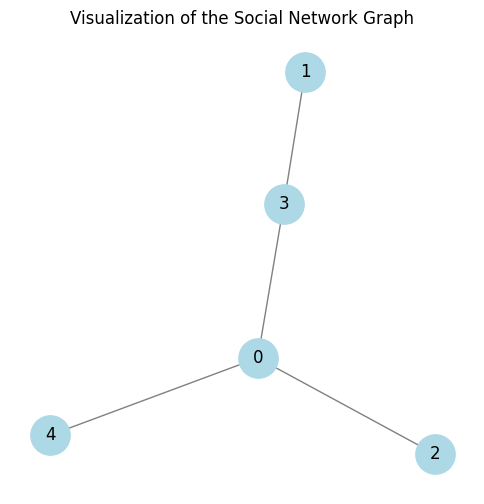

Number of friends: tensor([3, 1, 1, 2, 1])
Popularity labels: tensor([1, 0, 0, 1, 0])
Epoch 0, Loss: 0.6635
Epoch 20, Loss: 0.6454
Epoch 40, Loss: 0.6164
Epoch 60, Loss: 0.5878
Epoch 80, Loss: 0.5568
Epoch 100, Loss: 0.5241
Epoch 120, Loss: 0.4914
Epoch 140, Loss: 0.4610
Epoch 160, Loss: 0.4343
Epoch 180, Loss: 0.4114
Epoch 200, Loss: 0.3914
Epoch 220, Loss: 0.3733
Epoch 240, Loss: 0.3566
Epoch 260, Loss: 0.3408
Epoch 280, Loss: 0.3259
Epoch 300, Loss: 0.3117
Epoch 320, Loss: 0.2984
Epoch 340, Loss: 0.2857
Epoch 360, Loss: 0.2736
Epoch 380, Loss: 0.2623

Final Predictions (1=Popular, 0=Not Popular): [1, 0, 0, 0, 0]


In [23]:
import os
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

# Define graph dataset (MODIFICADO)
edge_index = torch.tensor([
    [0, 2, 0, 4, 3, 0, 3, 1],  # ← se agregan 3→0
    [2, 0, 4, 0, 0, 3, 1, 3],  # ← se agregan 0→3
], dtype=torch.long)

print(edge_index.shape)

#------------------------------------------------------------------------
# VISUALIZACION DEL GRAFO
# Convert the edge_index tensor to a list of edge tuples
edge_list = edge_index.t().tolist()

# Create a NetworkX graph from the edge list
G = nx.Graph()
G.add_edges_from(edge_list)

# Optionally, include nodes that might be isolated (e.g., person 3)
G.add_nodes_from(range(node_features.size(0)))

# Generate a layout for the nodes
pos = nx.spring_layout(G, seed=42)  # fixed seed for reproducibility

# Draw the graph with labels
plt.figure(figsize=(6, 6))
nx.draw_networkx(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=800)
plt.title("Visualization of the Social Network Graph")
plt.axis('off')
plt.show()
#------------------------------------------------------------------------


# Define data features
node_features = torch.tensor([
    [25, 1],  # Person 0 (25 years old, likes sports)
    [30, 0],  # Person 1 (30 years old, does not like sports)
    [22, 1],  # Person 2 (22 years old, likes sports)
    [35, 0],  # Person 3 (35 years old, does not like sports)
    [27, 1],  # Person 4 (27 years old, likes sports)
], dtype=torch.float)

# Compute number of friends automatically
num_nodes = node_features.shape[0]

num_friends = torch.bincount(
    edge_index[0],
    minlength=num_nodes
)

print("Number of friends:", num_friends)

# Define labels automatically
labels = (num_friends >= 2).long()
print("Popularity labels:", labels)

# Mask for separating training and testing data
train_mask = torch.tensor([1, 1, 1, 0, 0], dtype=torch.bool)
data = Data(x=node_features, edge_index=edge_index, y=labels, train_mask=train_mask)

# Define model
class GNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim) 
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)  # Activation function
        x = self.conv2(x, edge_index)
        return x

# Instantiate model
model = GNN(input_dim=2, hidden_dim=4, output_dim=2)

# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train model
for epoch in range(400):
    model.train()
    optimizer.zero_grad()
    
    out = model(data)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


# Test model
model.eval()
with torch.no_grad():
    predictions = model(data).argmax(dim=1)

print("\nFinal Predictions (1=Popular, 0=Not Popular):", predictions.tolist())